In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad

In [5]:
Om = 0.3
H0 = 73
q0 = -0.55
j0 = 1
s0 = -0.35
l0 = 3.115
c = 299792.458#km/s
z = np.linspace(0,5, 2000)

In [3]:
def Ez(z, dc, Om):
    return 1/np.sqrt(Om*(1+z)**3+1-Om)

def DcLCDM(z, theta):
    sol = solve_ivp(Ez, [z[0],z[-1]], [0.0], t_eval=z, args=(Om,), method='RK45')

    return sol.y[0]

In [4]:
def Ez(z, theta):
    H0, Om = theta
    return np.sqrt(Om*(1+z)**3+1-Om)

def DcLCDM(z, theta):
    dc = np.zeros_like(z)

    ez = lambda z2, theta: 1/Ez(z2, theta)
    
    for i in range(len(z)):
        if i == 0:
            dc[i], _ = quad(ez, 0, z[i], args=(theta), epsabs=1e-05, epsrel=1e-05)
            if not np.isfinite(dc[i]):
                dc[i] = np.inf
        else:
            dc_aux, _ = quad(ez, z[i-1], z[i], args=(theta), epsabs=1e-05, epsrel=1e-05)
            dc[i] = dc_aux + dc[i-1]
            if not np.isfinite(dc[i]):
                dc[i] = np.inf
    return dc

In [10]:
def EzP21(z, theta):
    H0, q0, j0 = theta

    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))

    hz = ((1 + b1 * z) ** 2) / (a1 + a2 * z * (2 + b1 * z))

    return hz

def EzP22(z, theta):
    H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    hz = ((1 + b1 * z + b2 * (z ** 2)) ** 2) / (a1 -(a1 * b2 * (z ** 2)) + a2 *z * (2 + b1 * z))

    return hz/H0

def EzP31(z, theta):
    H0, q0, j0, s0 = theta

    a1 = 1/H0
    a2 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 **3) + s0))/(4*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    a3 = ((2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 **4)
          -3 * s0 -3 * q0 * s0)) /(24*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    b1 = ((-6 + 9 * j0 -18 * q0 + 10 * j0 * q0 -27 * (q0 ** 2) -15 *(q0 ** 3) + s0)) / (4*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))

    hz = ((1 + b1 * z) ** 2) / (a1 + z * (a2 * (2 + b1 * z) + a3 * z * (3 + 2 *b1 * z)))

    return hz/H0

def EzP32(z, theta):
    H0, q0, j0, s0, l0 = theta

    a1 = 1/H0
    a2 = (-14 + 137 * j0 + 10 * (j0 ** 2) + 6 * l0 -70 * q0 + 472 * j0 * q0 + 20 * (j0 ** 2) * q0 + 6 * l0 * q0 -277 * (q0 ** 2) + 495 * j0 * (q0 ** 2)
         -551 * (q0 ** 3) + 150 * j0 * (q0 ** 3) -465 * (q0 ** 4) -135 * (q0 ** 5) + 61 * s0 + 10 * j0 * s0 + 116 * q0 * s0 + 45 * (q0 ** 2) * s0) / (10*H0*(-2 + 11 * j0
         + 4 * (j0 ** 2) -8 * q0 + 25 * j0 * q0 -23 * (q0 ** 2) + 6 * j0 * (q0 ** 2) -30 * (q0 ** 3) -9 * (q0 ** 4) + 3 * s0 + 3 * q0 * s0))
    a3 = ((-4 + 60 * j0 -9 * (j0 ** 2) + 80 * (j0 ** 3) + 6 * l0 -12 * j0 * l0 -24 * q0 + 276 * j0 * q0 + 12 * l0 * q0 -120 * (q0 ** 2)
         + 468 * j0 * (q0 ** 2) -180 * (j0 ** 2) * (q0 ** 2) + 18 * l0 * (q0 ** 2) -320 * (q0 ** 3) + 330 * j0 * (q0 ** 3) -423 * (q0 ** 4) + 270 * j0 * (q0 ** 4)
         -270 * (q0 ** 5) -135 * (q0 ** 6) + 36 * s0 + 18 * j0 * s0 + 102 * q0 * s0 + 60 * j0 * q0 * s0 + 78 * (q0 ** 2) * s0 + 15 * (s0 ** 2))) / (60*H0*(-2 + 11 * j0 +
         4 * (j0 ** 2) -8 * q0 + 25 * j0 * q0 -23 * (q0 ** 2) + 6 * j0 * (q0 ** 2) -30 * (q0 ** 3) -9 * (q0 ** 4) + 3 * s0 + 3 * q0 * s0))
    b1 = (12 -96 * j0 -15 * (j0 ** 2) -3 * l0 + 60 * q0 -326 * j0 * q0 -20 * (j0 ** 2) * q0 -3 * l0 * q0 + 216 * (q0 ** 2) -325 * j0 * (q0 ** 2) + 408 * (q0 ** 3)
         -90 * j0 * (q0 ** 3) + 330 * (q0 ** 4) + 90 * (q0 ** 5) -38 * s0 -5 * j0 * s0 -73 * q0 * s0 -30 * (q0 ** 2) * s0) / (10 -55 * j0 -20 * (j0 ** 2) + 40 * q0
         -125 * j0 * q0 + 115 * (q0 ** 2) -30 * j0 * (q0 ** 2) + 150 * (q0 ** 3) + 45 * (q0 ** 4) -15 * s0 -15 * q0 * s0)
    b2 = (12 -132 * j0 -37 * (j0 ** 2) -40 * (j0 ** 3) -8 * l0 + 4 * j0 * l0 + 72 * q0 -596 * j0 * q0 -100 * (j0 ** 2) * q0 -16 * l0 * q0 + 312 * (q0 ** 2)
         -898 * j0 * (q0 ** 2) + 40 * (j0 ** 2) * (q0 ** 2) -12 * l0 * (q0 ** 2) + 768 * (q0 ** 3) -510 * j0 * (q0 ** 3) + 927 * (q0 ** 4) -180 * j0 * (q0 ** 4)
         + 510 * (q0 ** 5) + 135 * (q0 ** 6) -68 * s0 -26 * j0 * s0 -196 * q0 * s0 -40 * j0 * q0 * s0 -162 * (q0 ** 2) * s0 -30 * (q0 ** 3) * s0 -5 * (s0 ** 2)) / (40
         -220 * j0 -80 * (j0 ** 2) + 160 * q0 -500 * j0 * q0 + 460 * (q0 ** 2) -120 * j0 * (q0 ** 2) + 600 * (q0 ** 3) + 180 * (q0 ** 4) -60 * s0 -60 * q0 * s0)

    hz = ((1 + b1 * z + b2 * (z ** 2)) ** 2) / (a1 -(a1 * b2 * (z ** 2)) + z * (a2 * (2 + b1 * z) + a3 * z * (3 + 2 * b1 * z + b2 * (z ** 2))))

    return hz/H0

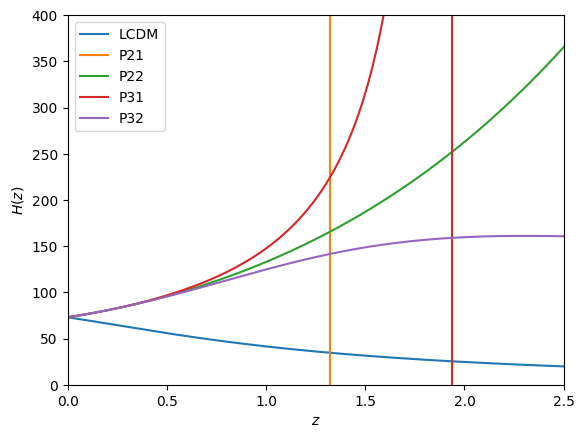

In [11]:
plt.plot(z, H0*Ez(z, 0, Om), label='LCDM')
plt.plot(z, H0*EzP21(z, [H0, q0, j0]), label='P21')
plt.plot(z, H0*EzP22(z, [H0, q0, j0, s0]), label='P22')
plt.plot(z, H0*EzP31(z, [H0, q0, j0, s0]), label='P31')
plt.plot(z, H0*EzP32(z, [H0, q0, j0, s0, l0]), label='P32')
plt.plot()
plt.legend()
plt.xlim(0,2.5)
plt.ylim(0,400)
plt.xlabel('$z$')
plt.ylabel('$H (z)$')
plt.show()

In [12]:
def dCP21(z, theta):
    H0, q0, j0 = theta
    
    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))

    dc = (a1*z+a2*z**2)/(1+b1*z)

    return c*dc

def dCP22(z, theta):
    H0, q0, j0, s0 = theta
    
    a1 = 1/H0
    a2 = ((-1 + 5 * j0 -3 * q0 + 6 * j0 * q0 -8 * (q0 ** 2) -6 * (q0 ** 3) + s0)) / (2*H0*((-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2))))
    b1 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 ** 3) + s0)) /(2*(-1 + 2 * j0 -2 * q0 -3 * (q0 ** 2)))
    b2 = (2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 ** 4) -3 * s0
          -3 * q0 *s0) / (12 -24 * j0 + 24 * q0 + 36 * (q0 ** 2))

    dc = (a1*z + a2*z**2)/(1+b1*z+b2*z**2)
    
    return c*dc

def dCP31(z, theta):
    H0, q0, j0, s0 = theta

    a1 = 1/H0
    a2 = ((-2 + 7 * j0 -6 * q0 + 8 * j0 * q0 -13 * (q0 ** 2) -9 * (q0 **3) + s0))/(4*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    a3 = ((2 -11 * j0 -4 * (j0 ** 2) + 8 * q0 -25 * j0 * q0 + 23 * (q0 ** 2) -6 * j0 * (q0 ** 2) + 30 * (q0 ** 3) + 9 * (q0 **4)
          -3 * s0 -3 * q0 * s0)) /(24*H0*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))
    b1 = ((-6 + 9 * j0 -18 * q0 + 10 * j0 * q0 -27 * (q0 ** 2) -15 *(q0 ** 3) + s0)) / (4*(-2 + j0 -4 * q0 -3 * (q0 ** 2)))

    dc = (a1*z + a2*z**2 + a3*z**3)/(1 + b1*z)

    return c*dc

def dCP32(z, theta):
    H0, q0, j0, s0, l0 = theta

    a1 = 1/H0
    a2 = (-14 + 137 * j0 + 10 * (j0 ** 2) + 6 * l0 -70 * q0 + 472 * j0 * q0 + 20 * (j0 ** 2) * q0 + 6 * l0 * q0 -277 * (q0 ** 2) + 495 * j0 * (q0 ** 2)
         -551 * (q0 ** 3) + 150 * j0 * (q0 ** 3) -465 * (q0 ** 4) -135 * (q0 ** 5) + 61 * s0 + 10 * j0 * s0 + 116 * q0 * s0 + 45 * (q0 ** 2) * s0) / (10*H0*(-2 + 11 * j0
         + 4 * (j0 ** 2) -8 * q0 + 25 * j0 * q0 -23 * (q0 ** 2) + 6 * j0 * (q0 ** 2) -30 * (q0 ** 3) -9 * (q0 ** 4) + 3 * s0 + 3 * q0 * s0))
    a3 = ((-4 + 60 * j0 -9 * (j0 ** 2) + 80 * (j0 ** 3) + 6 * l0 -12 * j0 * l0 -24 * q0 + 276 * j0 * q0 + 12 * l0 * q0 -120 * (q0 ** 2)
         + 468 * j0 * (q0 ** 2) -180 * (j0 ** 2) * (q0 ** 2) + 18 * l0 * (q0 ** 2) -320 * (q0 ** 3) + 330 * j0 * (q0 ** 3) -423 * (q0 ** 4) + 270 * j0 * (q0 ** 4)
         -270 * (q0 ** 5) -135 * (q0 ** 6) + 36 * s0 + 18 * j0 * s0 + 102 * q0 * s0 + 60 * j0 * q0 * s0 + 78 * (q0 ** 2) * s0 + 15 * (s0 ** 2))) / (60*H0*(-2 + 11 * j0 +
         4 * (j0 ** 2) -8 * q0 + 25 * j0 * q0 -23 * (q0 ** 2) + 6 * j0 * (q0 ** 2) -30 * (q0 ** 3) -9 * (q0 ** 4) + 3 * s0 + 3 * q0 * s0))
    b1 = (12 -96 * j0 -15 * (j0 ** 2) -3 * l0 + 60 * q0 -326 * j0 * q0 -20 * (j0 ** 2) * q0 -3 * l0 * q0 + 216 * (q0 ** 2) -325 * j0 * (q0 ** 2) + 408 * (q0 ** 3)
         -90 * j0 * (q0 ** 3) + 330 * (q0 ** 4) + 90 * (q0 ** 5) -38 * s0 -5 * j0 * s0 -73 * q0 * s0 -30 * (q0 ** 2) * s0) / (10 -55 * j0 -20 * (j0 ** 2) + 40 * q0
         -125 * j0 * q0 + 115 * (q0 ** 2) -30 * j0 * (q0 ** 2) + 150 * (q0 ** 3) + 45 * (q0 ** 4) -15 * s0 -15 * q0 * s0)
    b2 = (12 -132 * j0 -37 * (j0 ** 2) -40 * (j0 ** 3) -8 * l0 + 4 * j0 * l0 + 72 * q0 -596 * j0 * q0 -100 * (j0 ** 2) * q0 -16 * l0 * q0 + 312 * (q0 ** 2)
         -898 * j0 * (q0 ** 2) + 40 * (j0 ** 2) * (q0 ** 2) -12 * l0 * (q0 ** 2) + 768 * (q0 ** 3) -510 * j0 * (q0 ** 3) + 927 * (q0 ** 4) -180 * j0 * (q0 ** 4)
         + 510 * (q0 ** 5) + 135 * (q0 ** 6) -68 * s0 -26 * j0 * s0 -196 * q0 * s0 -40 * j0 * q0 * s0 -162 * (q0 ** 2) * s0 -30 * (q0 ** 3) * s0 -5 * (s0 ** 2)) / (40
         -220 * j0 -80 * (j0 ** 2) + 160 * q0 -500 * j0 * q0 + 460 * (q0 ** 2) -120 * j0 * (q0 ** 2) + 600 * (q0 ** 3) + 180 * (q0 ** 4) -60 * s0 -60 * q0 * s0)

    dc = (a1*z + a2*z**2 + a3*z**3)/(1 + b1*z + b2*z**2)

    return H0*dc

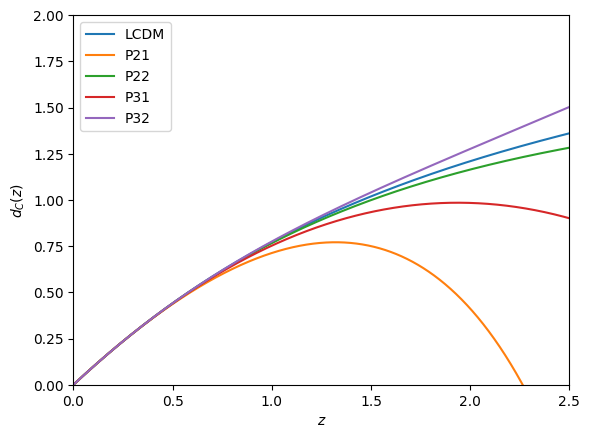

In [14]:
plt.plot(z, DcLCDM(z, Om), label='LCDM')
plt.plot(z, (H0/c)*dCP21(z, [H0, q0, j0]), label='P21')
plt.plot(z, (H0/c)*dCP22(z, [H0, q0, j0, s0]), label='P22')
plt.plot(z, (H0/c)*dCP31(z, [H0, q0, j0, s0]), label='P31')
plt.plot(z, dCP32(z, [H0, q0, j0, s0, l0]), label='P32')
plt.legend()
plt.xlim(0,2.5)
plt.ylim(0,2)
plt.xlabel('$z$')
plt.ylabel('$d_C (z)$')
#plt.savefig('HzTeste_NoP22.jpg')
plt.show()